#### Using Taylor Series function $f(x+ t)$ can be written as:

$f(x_{k}+t)\approx f(x_{k})+f'(x_{k})t+{\frac {1}{2}}f''(x_{k})t^{2} +\cdots$


Assume that we have a function :

$f(x) =  ax^2+bx+c$               

with $a>0$ 


To find minimum value of $f(x_{k}+t)$ we lets take Derivative wrt t:

$ 0={\frac {\rm {d}}{{\rm {d}}t}}\left(f(x_{k})+f'(x_{k})t+{\frac {1} {2}}f''(x_{k})t^{2}\right)=f'(x_{k})+f''(x_{k})t$


we get minimum at :

$t=-{\frac {f'(x_{k})}{f''(x_{k})}} $


which means function f(x) ,attains minimum value at $f(x_{k}-{\frac {f'(x_{k})}{f''(x_{k})}})$


for $f(x) = ax^2+bx+c$

$x_{k}-{\frac {f'(x_{k})}{f''(x_{k})}} = x_k - {\frac {2*a*x+b}{2*a}}$

for any $x_k$ if we know f(x) we can find minimum in one step given we knew the loss function 

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(-15,15,0.1)

a = np.random.randint(1,10)
b = np.random.randint(-10,10)
c = np.random.randint(-10,10)

print("a={},b={},c={}".format(a,b,c))

y = a*np.square(x)+b*x+c

a=8,b=5,c=-7


In [2]:
# now lets select a random no:
X_init =  np.random.randint(-10,10)

X_optimal = X_init - (2*a*X_init+b)/(2*a)

#### we selected initial point as a random no 

#### but with just one step of upgrade we were able to reach to the global minima , this is when we already know the loss function ,but in general we donot have loss function before hand

Text(1.6875, 92.21875, 'X_optimal')

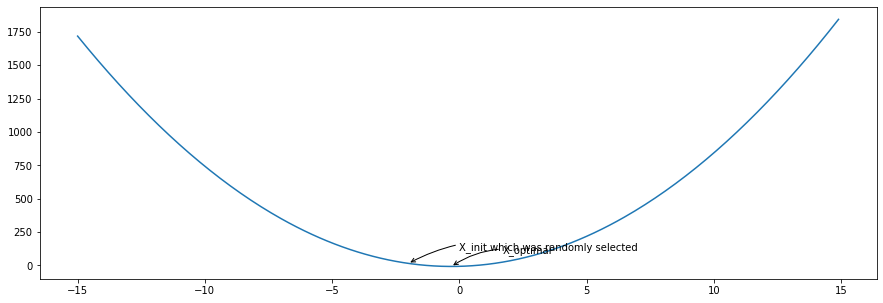

In [3]:
plt.figure(figsize=(15,5))
ax1 = plt.subplot(1, 1, 1)
plt.plot(x,y)

ax1.annotate('X_init which was randomly selected',
            xy=(X_init,a*np.square(X_init)+b*X_init+c), 
            xycoords=ax1.transData,
            xytext=(X_init+2,a*np.square(X_init)+b*X_init+c+100), 
            textcoords=ax1.transData,
            arrowprops=dict(arrowstyle="->",
                            connectionstyle="arc3,rad=.2"))


ax1.annotate('X_optimal',
            xy=(X_optimal,a*np.square(X_optimal)+b*X_optimal+c), 
            xycoords=ax1.transData,
            xytext=(X_optimal+2,a*np.square(X_optimal)+b*X_optimal+c+100), 
            textcoords=ax1.transData,
            arrowprops=dict(arrowstyle="->",
                            connectionstyle="arc3,rad=.2"))

Here we choosed a random quardatic equation and then choosed random point and tried to get to minimum in one step.

we knew the equation and so we were able to reach the minimum in one go , but actually we don't have it before hand 


Now if we are using this eq to update our parameter:

$x_{k+1} = x_{k}- \eta *f'(x_{k})$

insted of using :

$x_{k+1} = x_{k}-{\frac {f'(x_{k})}{f''(x_{k})}}$


than we know :

that $\eta = {\frac {1}{f''(x_{k})}}$  will take us close to the minima 

and since quardatic equation is symetric 

#### $\eta = 2* {\frac {1}{f''(x_{k})}}$ 

will take us close to the symetric point about the minima (for which the cost is similar)

#### for $\eta > 2* {\frac {1}{f''(x_{k})}}$ gradient decent is going to diverge , Varience of change in parameters between two iterations will increase with iteration.

#### for $2* {\frac {1}{f''(x_{k})}} > \eta >  {\frac {1}{f''(x_{k})}}$ , gradient decent will converge ,Varience of change in parameters between two iterations will decrease with iteration. and mean of parameters will move towards minima 

#### for ${\frac {1}{f''(x_{k})}} > \eta $ , gradient decent will converge ,Varience of change in parameters between two iterations will decrease with iteration. and mean of parameters will move towards minima slowly

### since we do not know loss function before hand , we use moving average and variance of parameter to decide learning rate

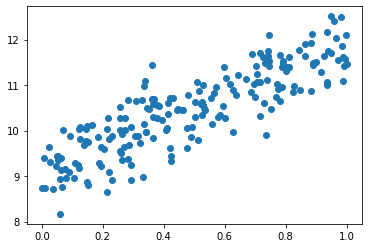

In [4]:
no_of_samples = 200
noice = np.random.randn(no_of_samples)

x = np.random.random([200,1])

y = 3*x[:,0]+ 9 + 0.5*noice

plt.scatter(x,y)

In [5]:
def calculate_y(x,m,c):
    return m*x+c


def calulate_mse(y,x,m,c):
    sum_se = 0
    for index in range(x.shape[0]):
        y_calculated = calculate_y(x[index,0],m,c)
        se = (y_calculated-y[index])**2
        sum_se = sum_se + se
    return sum_se/x.shape[0]

def linear_regression(x,y,learning_rate):
    m = np.random.rand()
    c = np.random.rand()
    mse = []

    for i in range(1000):
        update_m = 0
        update_c = 0
        for index in range(x.shape[0]):
            y_calculated = calculate_y(x[index,0],m,c)
            y_actual = y[index]
            update_m += (y_actual - y_calculated)*x[index]
            update_c += (y_actual - y_calculated)
        m += learning_rate*update_m
        c += learning_rate*update_c

        mse.append(calulate_mse(y,x,m,c))
    return [m,c],mse

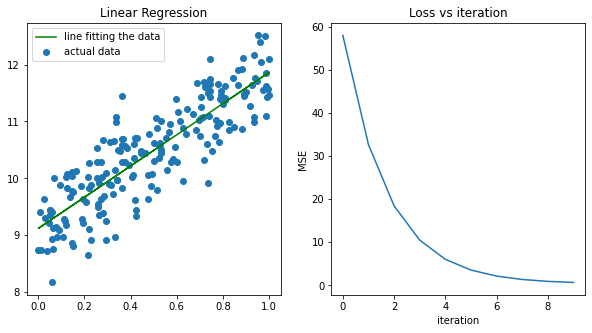

In [6]:
learning_rate = 0.001
[parameters,mse_1] = linear_regression(x,y,learning_rate)

m = parameters[0]
c = parameters[1]

plt.figure(figsize=(10,5))
plt.title('line fitting the data')
plt.subplot(121)
plt.plot(x,m*x+c,color='green')
plt.scatter(x, y)
plt.legend(('line fitting the data', 'actual data'))
plt.title('Linear Regression')


plt.subplot(122)
plt.plot(mse_1[:10])
plt.xlabel("iteration")
plt.ylabel("MSE")
plt.title('Loss vs iteration')
plt.show()

[array([-2.24473432e+17]), array([-4.26241141e+17])]


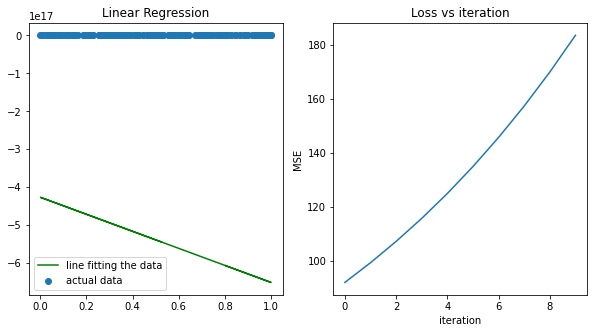

In [7]:
learning_rate = 0.0081
[parameters,mse_2] = linear_regression(x,y,learning_rate)
print(parameters)
m = parameters[0]
c = parameters[1]

plt.figure(figsize=(10,5))
plt.title('line fitting the data')
plt.subplot(121)
plt.plot(x,m*x+c,color='green')
plt.scatter(x, y)
plt.legend(('line fitting the data', 'actual data'))
plt.title('Linear Regression')


plt.subplot(122)
plt.plot(mse_2[:10])
plt.xlabel("iteration")
plt.ylabel("MSE")
plt.title('Loss vs iteration')
plt.show()

[array([3.20506678]), array([8.87704275])]


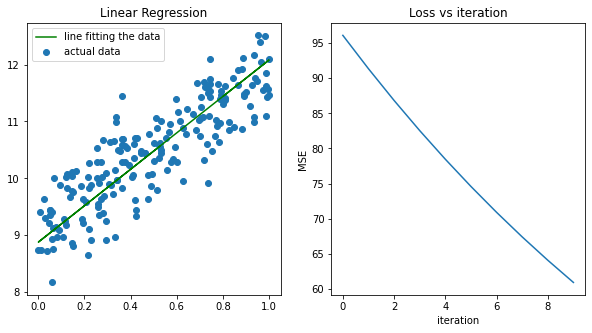

In [8]:
learning_rate = 0.0001
[parameters,mse_3] = linear_regression(x,y,learning_rate)
print(parameters)
m = parameters[0]
c = parameters[1]

plt.figure(figsize=(10,5))
plt.title('line fitting the data')
plt.subplot(121)
plt.plot(x,m*x+c,color='green')
plt.scatter(x, y)
plt.legend(('line fitting the data', 'actual data'))
plt.title('Linear Regression')


plt.subplot(122)
plt.plot(mse_3[:10])
plt.xlabel("iteration")
plt.ylabel("MSE")
plt.title('Loss vs iteration')
plt.show()

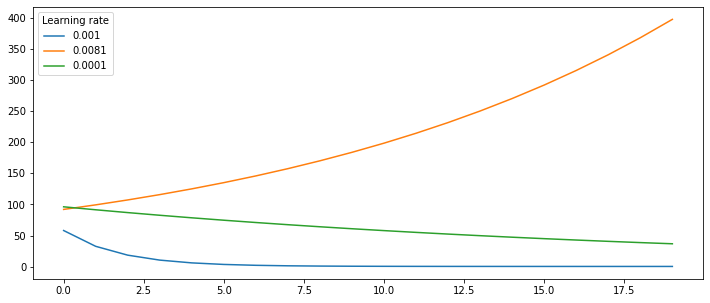

In [10]:
plt.figure(figsize=(12,5))
plt.plot(mse_1[:20],label='0.001')
plt.plot(mse_2[:20],label='0.0081')
plt.plot(mse_3[:20],label='0.0001')

plt.legend()
plt.legend(title='Learning rate')